In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
# DataFrame ejemplo
data = pd.DataFrame({
    'Nombre': ['Juan', 'Ana'],
    '2021': [100, 200],
    '2022': [150, 250]
})

print(data)

  Nombre  2021  2022
0   Juan   100   150
1    Ana   200   250


In [19]:
apilado = data.set_index('Nombre').stack()
print(apilado)

Nombre      
Juan    2021    100
        2022    150
Ana     2021    200
        2022    250
dtype: int64


In [20]:
type(apilado)

pandas.core.series.Series

In [8]:
# apilado.to_excel("../data/processed/stac.xlsx")
apilado.to_csv("../data/processed/stac.txt", sep=',')

In [9]:
data = pd.DataFrame({
    'A': [1, 2, None],
    'B': [None, 3, 4]
})

print(data.stack())

0  A    1.0
1  A    2.0
   B    3.0
2  B    4.0
dtype: float64


## Ejemplo 1: Preparar datos para un gráfico de líneas
Tengo un DataFrame con los datos de las ventas anuales de diferentes productos:

In [10]:
data = pd.DataFrame({
    'Producto': ['A', 'B', 'C'],
    '2021': [100, 200, 300],
    '2022': [150, 250, 350],
    '2023': [200, 300, 400]
})

print(data)

  Producto  2021  2022  2023
0        A   100   150   200
1        B   200   250   300
2        C   300   350   400


In [11]:
data_long = data.set_index('Producto').stack().reset_index()
data_long.columns = ['Producto', 'Año', 'Ventas']

print(data_long)

  Producto   Año  Ventas
0        A  2021     100
1        A  2022     150
2        A  2023     200
3        B  2021     200
4        B  2022     250
5        B  2023     300
6        C  2021     300
7        C  2022     350
8        C  2023     400


In [21]:
type(data_long)

pandas.core.frame.DataFrame

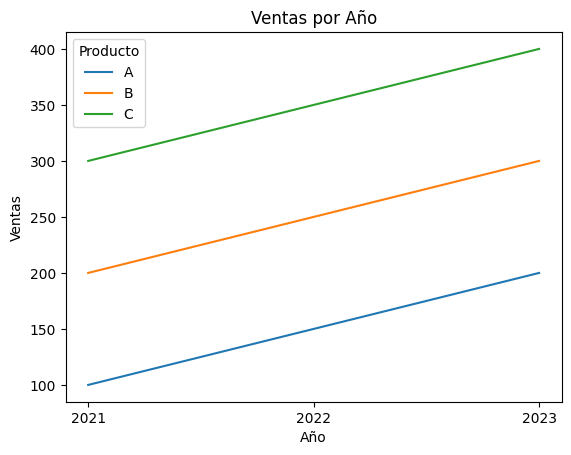

In [26]:
sns.lineplot(data=data_long, x='Año', y='Ventas', hue='Producto')
plt.title('Ventas por Año')
plt.savefig('../data/processed/mi_imagen.png') # para guardar antes de show
plt.savefig('../data/processed/mi_imagen.pdf', format='pdf') # para guardar antes de show
plt.show()

## Ejemplo 2: Distribuciones y gráficos de barras
Tengo datos de calificaciones en diferentes materias:

In [27]:
data = pd.DataFrame({
    'Estudiante': ['Juan', 'Ana', 'Pedro'],
    'Matemáticas': [85, 90, 78],
    'Historia': [88, 92, 80],
    'Ciencias': [89, 94, 84]
})

print(data)

  Estudiante  Matemáticas  Historia  Ciencias
0       Juan           85        88        89
1        Ana           90        92        94
2      Pedro           78        80        84


In [28]:
data_long = data.set_index('Estudiante').stack().reset_index()
data_long.columns = ['Estudiante', 'Materia', 'Calificación']

print(data_long)

  Estudiante      Materia  Calificación
0       Juan  Matemáticas            85
1       Juan     Historia            88
2       Juan     Ciencias            89
3        Ana  Matemáticas            90
4        Ana     Historia            92
5        Ana     Ciencias            94
6      Pedro  Matemáticas            78
7      Pedro     Historia            80
8      Pedro     Ciencias            84


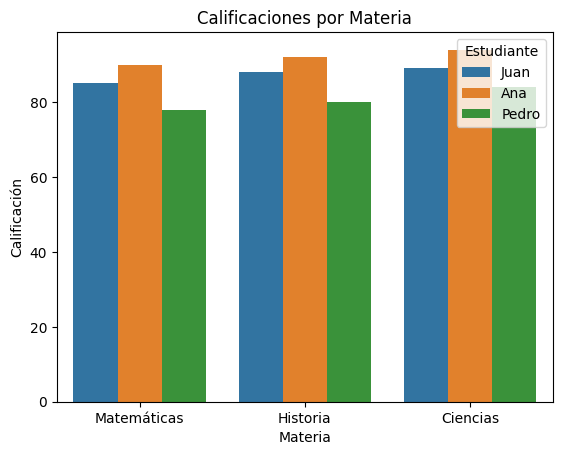

In [29]:
sns.barplot(data=data_long, x='Materia', y='Calificación', hue='Estudiante')
plt.title('Calificaciones por Materia')
plt.show()

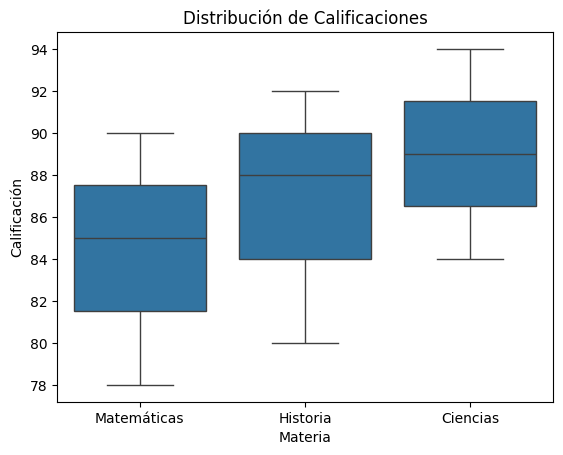

In [30]:
sns.boxplot(data=data_long, x='Materia', y='Calificación')
plt.title('Distribución de Calificaciones')
plt.show()

## Ejemplo 3: Análisis de datos temporales
Si tienes datos diarios de ventas y quieres analizarlos por meses o años, stack() puede ayudarte a reorganizarlos antes de realizar un análisis o graficar.

In [31]:
data = pd.DataFrame({
    'Fecha': ['2023-01-01', '2023-01-02', '2023-01-03'],
    'Producto A': [100, 150, 200],
    'Producto B': [200, 250, 300]
})

# Convertir a formato largo
data_long = data.set_index('Fecha').stack().reset_index()
data_long.columns = ['Fecha', 'Producto', 'Ventas']

print(data_long)

        Fecha    Producto  Ventas
0  2023-01-01  Producto A     100
1  2023-01-01  Producto B     200
2  2023-01-02  Producto A     150
3  2023-01-02  Producto B     250
4  2023-01-03  Producto A     200
5  2023-01-03  Producto B     300


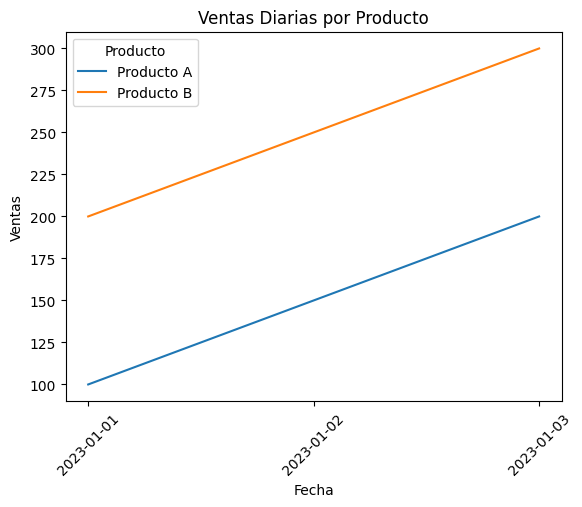

In [32]:
sns.lineplot(data=data_long, x='Fecha', y='Ventas', hue='Producto')
plt.title('Ventas Diarias por Producto')
plt.xticks(rotation=45)
plt.show()
